# Import Libraries

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np
from sklearn.cluster import KMeans

# Load Image Data from sklearn

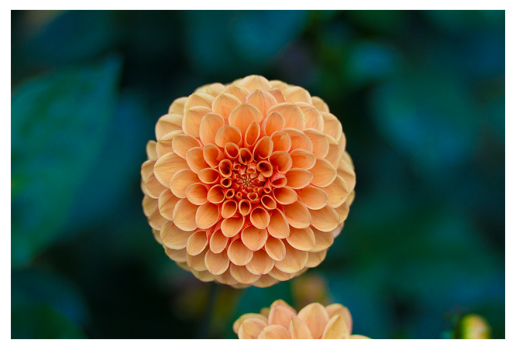

In [9]:
from sklearn.datasets import load_sample_image
china = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(china)
plt.show()

In [10]:
china.shape

(427, 640, 3)

In [11]:
data = china / 255.0 # use 0...1 scale
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

We can visualize these pixels in this color space, using a subset of 10,000 pixels for efficiency:

In [12]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data
    
    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

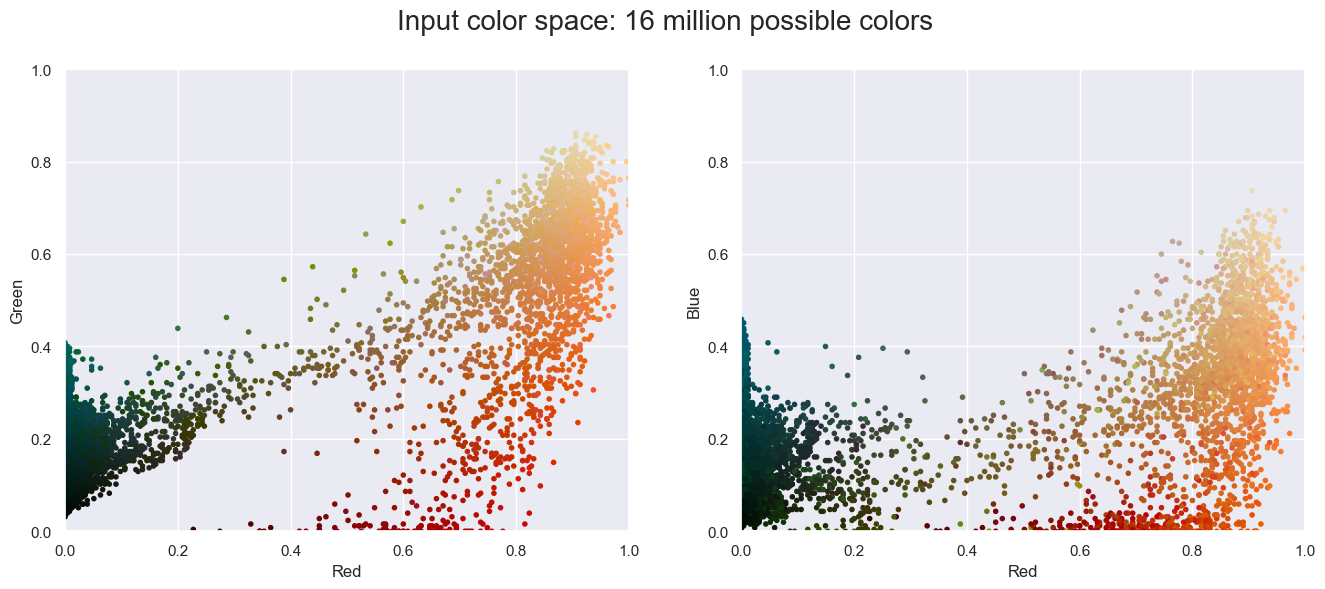

In [13]:
plot_pixels(data, title='Input color space: 16 million possible colors')

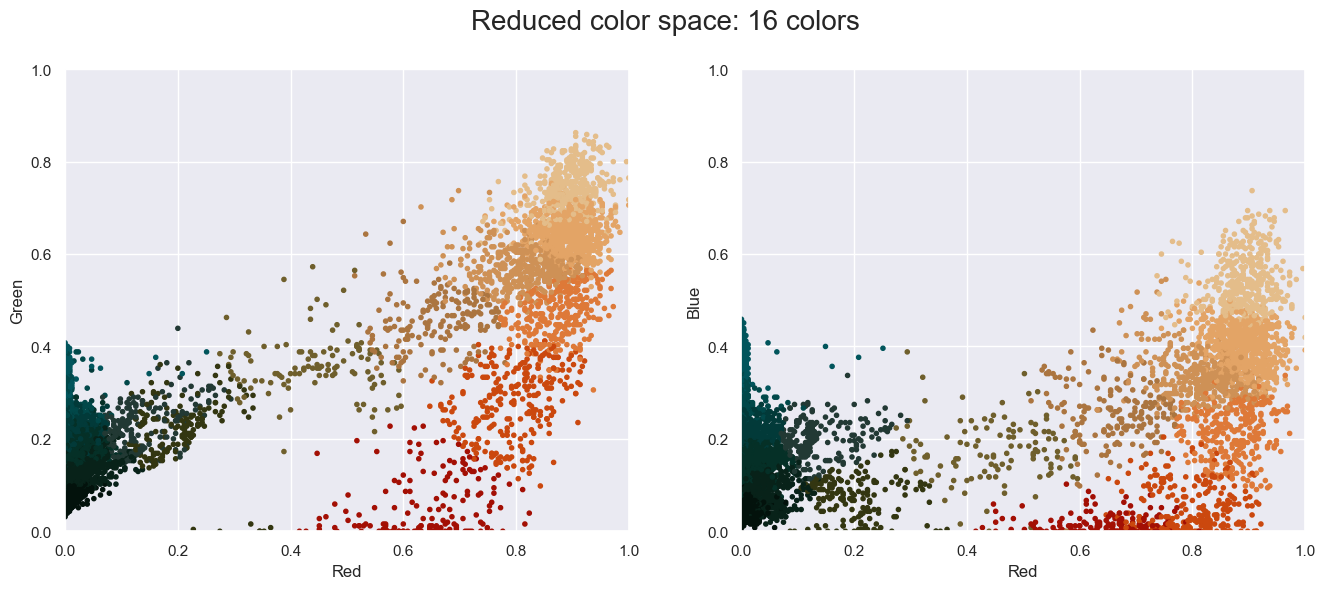

In [14]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Reduced color space: 16 colors")

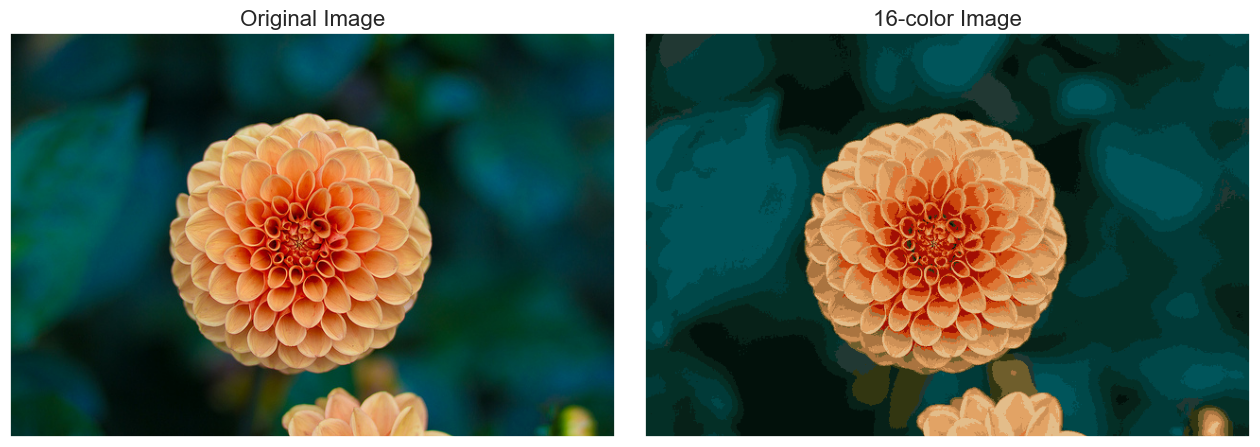

In [15]:
china_recolored = new_colors.reshape(china.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(china)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(china_recolored)
ax[1].set_title('16-color Image', size=16)
plt.show()

# Program-2 Image from Local system

In [16]:
import sys
!{sys.executable} -m pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable


In [27]:
import cv2
print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


In [17]:
# K-Means Image Color Compression using OpenCV and scikit-learn
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# --- Step 1: Load Image ---
# Replace with your image path
image_path = r"C:\Users\deepak.m\OneDrive\画像"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
plt.figure(figsize=(6,6))
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')
plt.show()

# --- Step 2: Reshape Image Data ---
pixel_values = image.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# --- Step 3: K-Means Clustering ---
k = 16  # number of colors to reduce to
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixel_values)
centers = np.uint8(kmeans.cluster_centers_)

# --- Step 4: Replace Pixels with Cluster Centers ---
compressed_pixels = centers[labels]
compressed_image = compressed_pixels.reshape(image.shape)

# --- Step 5: Show Compressed Image ---
plt.figure(figsize=(6,6))
plt.title(f"Compressed Image with {k} Colors")
plt.imshow(compressed_image)
plt.axis('off')
plt.show()

# --- Step 6: Save Compressed Image (optional) ---
output_path = r"C:\Users\deepak.m\OneDrive\画像"
cv2.imwrite(output_path, cv2.cvtColor(compressed_image, cv2.COLOR_RGB2BGR))
print(f"Compressed image saved to {output_path}")


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
